In [226]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import cmocean as cmo 
import matplotlib as mpl 
# get dates

# Create object 
class ModelResult:
    def __init__(self, fn, start_date, end_date, isave):
        self.ds = xr.open_dataset(fn, decode_timedelta=False)
        self.nt = len(self.ds.time.values)
        self.start_day = pd.to_datetime(start_date)
        self.end_day = pd.to_datetime(end_date)
        self.dates = pd.date_range(start_date, end_date, freq="10s")
        self.dates = self.dates[::isave]
        self.dates = self.dates[0:self.nt]
        print("There are %d saved profiles in this model..." % self.nt)

isave = 100

colors = ["#a4c639", "#73c2fb", "#d1001c", "#ff7f50", "#ceffb6", "#015185", "#ff1493", "#db7093", "#c71585", "#800080"]



m1 = ModelResult("2024_heat_flux_x1.0_noise1.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m2 = ModelResult("2024_heat_flux_x1.0_noise2.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m3 = ModelResult("2024_heat_flux_x1.0_noise3.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m4 = ModelResult("2024_heat_flux_x1.0_noise4.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m5 = ModelResult("2024_heat_flux_x1.0_noise5.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m6 = ModelResult("2024_heat_flux_x1.0_noise6.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
m7 = ModelResult("2024_heat_flux_x1.0_noise7.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)
# models_list = {'Wind x 1.0': m2024_01, 'Wind x 1.1': m2024_11, 'Wind x 0.9': m2024_09, 'Wind x 1.1 + noise (sigma=0.5)': m2024_11_noise,
#                'Wind x 1.0 + noise (sigma=0.5)': m2024_01_noise}
models_list = { '2': m2, 
               '1': m1,
               '3': m3,
               '4': m4,
               '5': m5,
               '6': m6,
               '7': m7}
models = models_list.keys()
# m2024_2 = ModelResult("2024_heat_flux.nc", "2024-08-06 00:00", "2024-08-07 00:00", isave)

Nm = len(models)

There are 87 saved profiles in this model...
There are 87 saved profiles in this model...
There are 87 saved profiles in this model...
There are 87 saved profiles in this model...
There are 87 saved profiles in this model...
There are 87 saved profiles in this model...
There are 87 saved profiles in this model...


In [227]:
# Define some plotting functions
def format_date_ax(ax, hours=2):
    """Format the x-axis of a plot with date labels."""
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=hours))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%d %H:%M"))
    ax.grid(alpha=0.25, which="both")
    # plt.setp(ax.get_xticklabels(), rotation=10, ha='right')   

def add_colorbar(fig, c):
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    cb = fig.colorbar(c, cax=cbar_ax, shrink=0.2)
    return cb 

Text(0.5, 1.0, 'Average temperature in 2024')

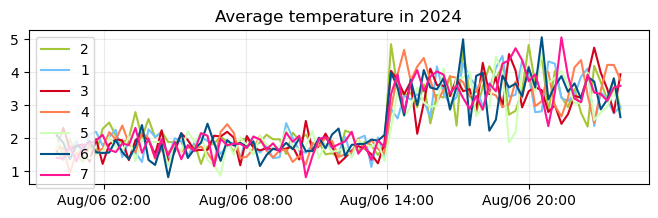

In [228]:
# Compare wind + heat forcings 
fn = "/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/"
wind_2024 = pd.read_csv(fn + "wind.csv")
heat_2024 = pd.read_csv(fn + "heat_flux2.csv")

fig2, ax2 = plt.subplots( figsize=(8, 2))

for im, model in enumerate(models):
    ds = models_list[model].ds
    ax2.plot(models_list[model].dates, ds['wind'], color=colors[im], label=model)
    # c1 = axs[im].pcolormesh(models_list[model].dates,-m2024_11.ds.z, m2024_11.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)

ax2.legend(loc="upper left")

format_date_ax(ax2, hours=6)
ax2.set_title("Average temperature in 2024")




(0.0, 5.0)

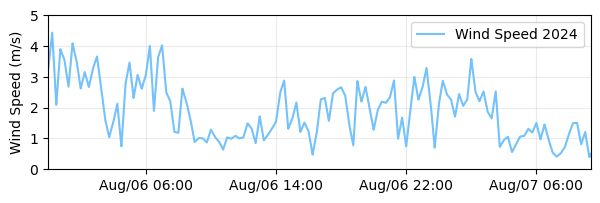

In [229]:
fig, axs = plt.subplots(1,1, figsize=(7, 2), sharex=False, sharey=True)
wtime = pd.to_datetime(wind_2024["time"])
axs.plot(wtime, wind_2024["WindSpeed"], label="Wind Speed 2024", color=colors[1])

format_date_ax(axs, hours=8)
axs.legend(loc="upper right") 
axs.set_ylabel("Wind Speed (m/s)")
axs.set_xlim(wtime[0], wtime[12000])
axs.set_ylim(0,5)



Text(0.5, 1.0, 'Average temperature in 2024')

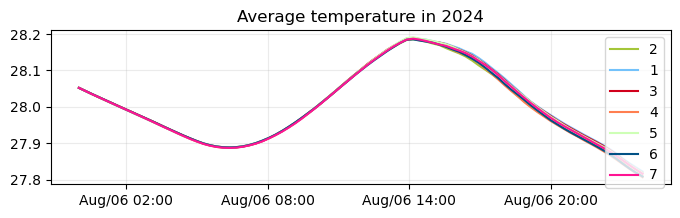

In [230]:
fig2, ax2 = plt.subplots( figsize=(8, 2))

for im, model in enumerate(models):
    ds = models_list[model].ds
    ax2.plot(models_list[model].dates, ds['C'].mean(dim='z'), color=colors[im], label=model)
    # c1 = axs[im].pcolormesh(models_list[model].dates,-m2024_11.ds.z, m2024_11.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)

ax2.legend(loc="upper right")


format_date_ax(ax2, hours=6)
ax2.set_title("Average temperature in 2024")

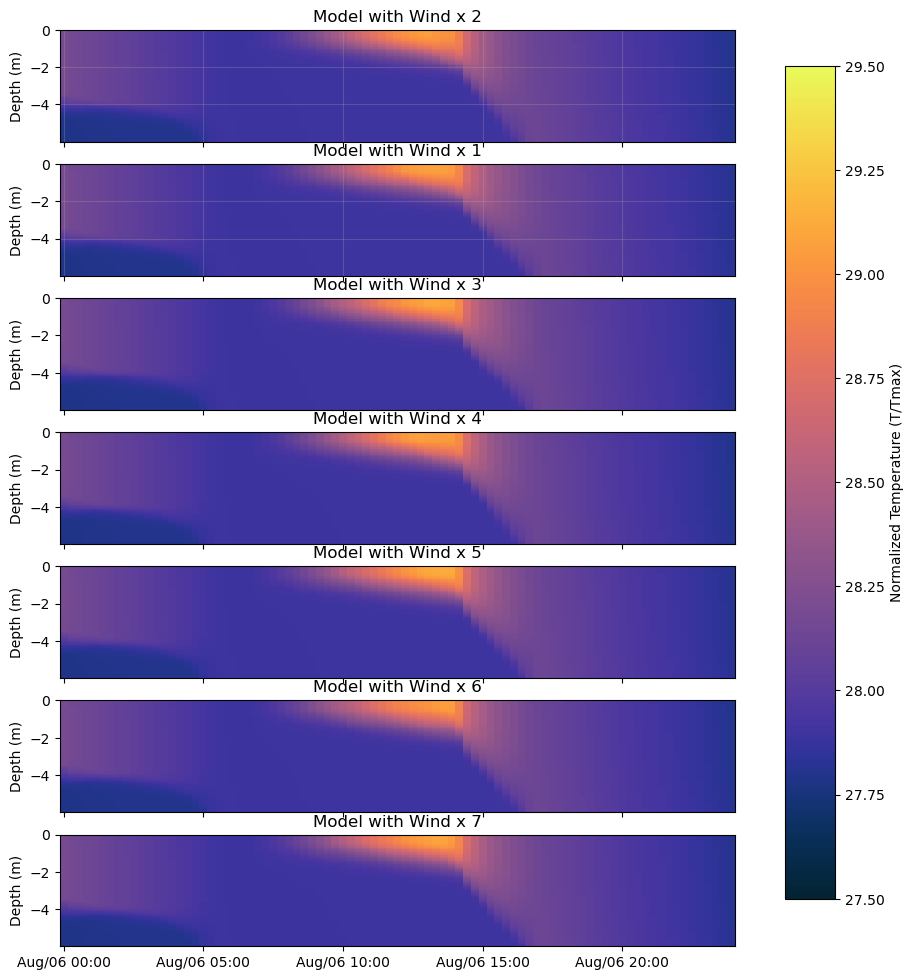

In [231]:
fig, axs = plt.subplots(figsize=(10, Nm*1.7), nrows=Nm, sharey=True, sharex=True)



vmin, vmax = 27.5, 29.5
# maxC = max(m2024_11.ds['C'].values.ravel())

for im, model in enumerate(models):
    ds = models_list[model].ds
    c1 = axs[im].pcolormesh(models_list[model].dates,-ds.z, ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    axs[im].set_title("Model with Wind x %s" % model)
    axs[im].set_ylabel('Depth (m)')
# c1 = axs[0].pcolormesh(m2024_01.dates,-m2024_01.ds.z, m2024_01.ds['C'].values.T,  cmap=cmo.cm.thermal, vmin=vmin, vmax=vmax) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)

format_date_ax(axs[0], hours=5)
format_date_ax(axs[1], hours=5)
cb = add_colorbar(fig, c1)
cb.set_label('Normalized Temperature (T/Tmax)')



# plt.tight_layout()

(87, 60)


Text(0, 0.5, 'Depth (m)')

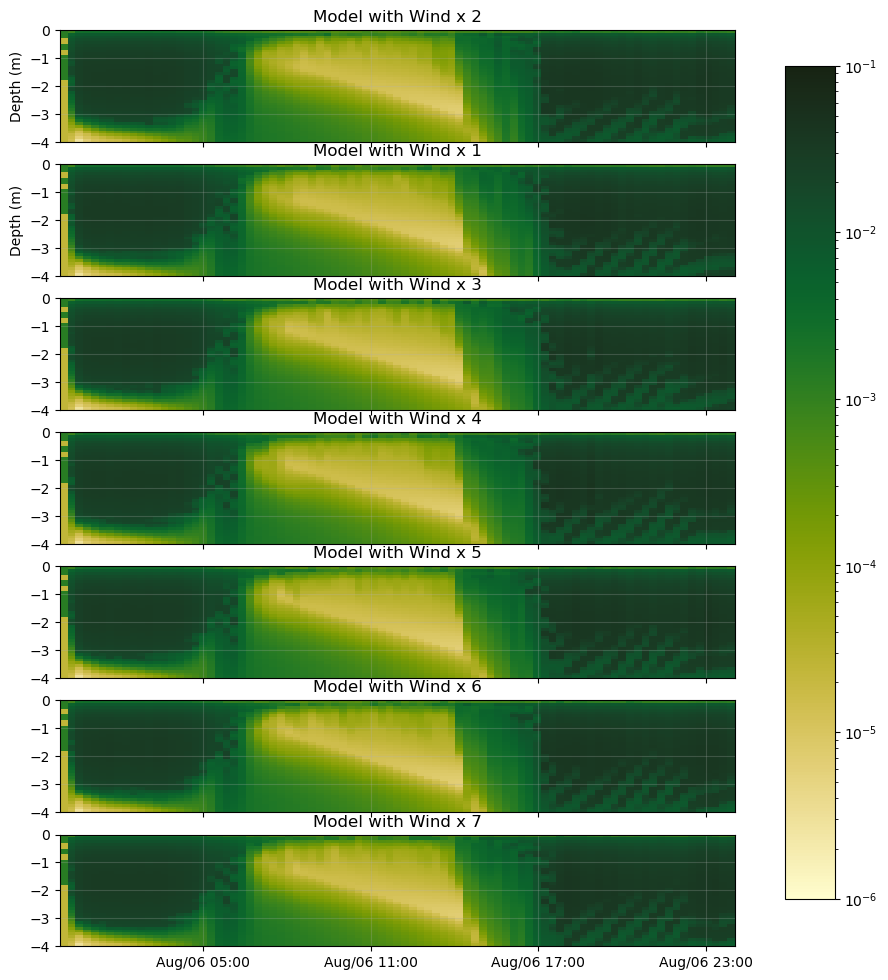

In [248]:
fig, axs = plt.subplots(figsize=(10,  Nm*1.7), nrows=Nm, sharey=True, sharex=True)

print(models_list['1'].ds['Kz'].shape)
average_diff = np.zeros((Nm,  models_list['1'].ds['Kz'].shape[0], models_list['1'].ds['Kz'].shape[1]))

for im, model in enumerate(models):
    ds = models_list[model].ds
    c1 = axs[im].pcolormesh(models_list[model].dates,-ds['Kz'].z, ds['Kz'].values.T, cmap=cmo.cm.speed, norm=mpl.colors.LogNorm(vmin=10e-7, vmax=10e-2)) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    average_diff[im,:,:] = ds['Kz'].values 
    axs[im].set_title("Model with Wind x %s" % model)
    format_date_ax(axs[im], hours=6)

average_diff = np.mean(average_diff, axis=0)
cb = add_colorbar(fig, c1)
axs[0].set_ylim(-4,0)

axs[0].set_ylabel('Depth (m)')
axs[1].set_ylabel('Depth (m)')

Text(0, 0.5, 'Depth (m)')

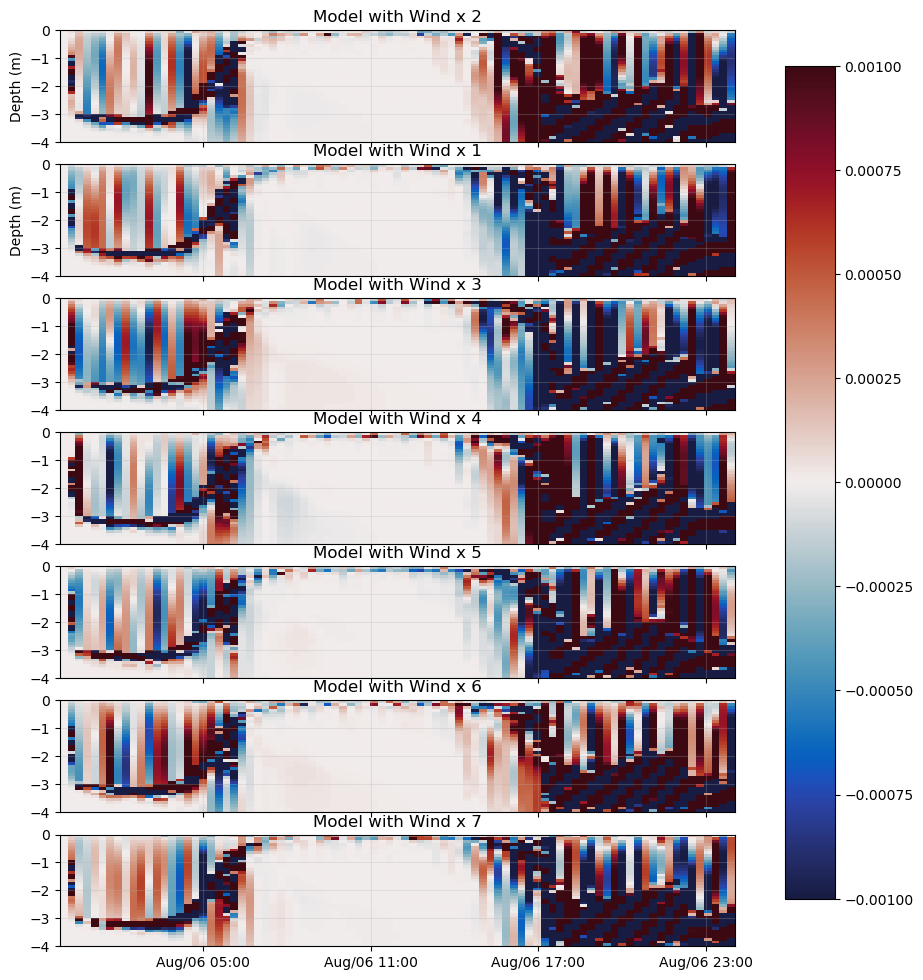

In [252]:
fig, axs = plt.subplots(figsize=(10,  Nm*1.7), nrows=Nm, sharey=True, sharex=True)

for im, model in enumerate(models):
    ds = models_list[model].ds
    kz = ds['Kz'].values - average_diff
    c1 = axs[im].pcolormesh(models_list[model].dates,-ds['Kz'].z, kz.T, cmap=cmo.cm.balance, vmin=-1e-3, vmax=1e-3)# norm=mpl.colors.LogNorm(vmin=10e-7, vmax=10e-2)) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    axs[im].set_title("Model with Wind x %s" % model)
    format_date_ax(axs[im], hours=6)

cb = add_colorbar(fig, c1)

axs[0].set_ylim(-4,0)

axs[0].set_ylabel('Depth (m)')
axs[1].set_ylabel('Depth (m)')

Text(0.5, 0.98, 'Diffusivity in the upper 2 m of the water column')

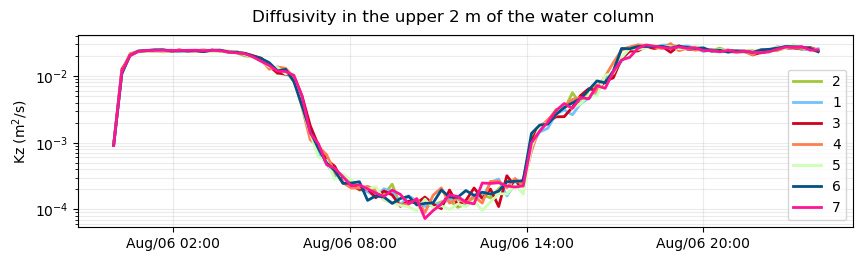

In [233]:
fig, axs = plt.subplots(figsize=(10, 2.5), nrows=1, sharey=True, sharex=False)

for im, model in enumerate(models):
    ds = models_list[model].ds
    kz = ds.Kz.sel(z=slice(2, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs.plot(models_list[model].dates, kz_av, color=colors[im], label=model, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)
format_date_ax(axs, hours=6)

axs.legend() 
axs.set_yscale("log")
axs.grid(alpha=0.25)
axs.set_ylabel('Kz (m$^2$/s)')
plt.suptitle("Diffusivity in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()


Text(0.5, 0.98, 'Brunt-Vaisala frequency in the upper 2 m of the water column')

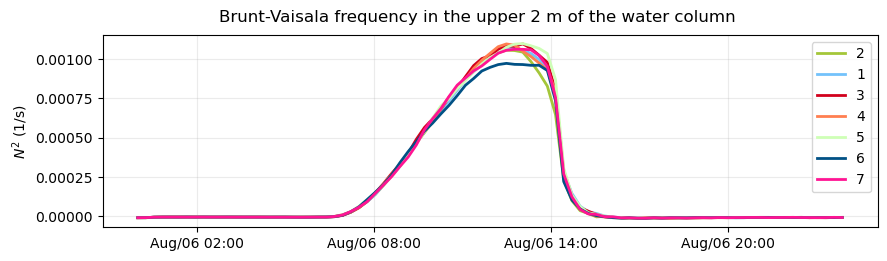

In [234]:
fig, axs = plt.subplots(figsize=(10, 2.5), nrows=1, sharey=True, sharex=False)

for im, model in enumerate(models):
    ds = models_list[model].ds
    kz = ds.N_BV2.sel(z=slice(2, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs.plot(models_list[model].dates, kz_av, color=colors[im], label=model, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
    # axs[im].set_title("Model with Wind x %s" % model)
format_date_ax(axs, hours=6)

axs.legend() 
axs.grid(alpha=0.25)
axs.set_ylabel('$N^2$ (1/s)')
plt.suptitle("Brunt-Vaisala frequency in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()


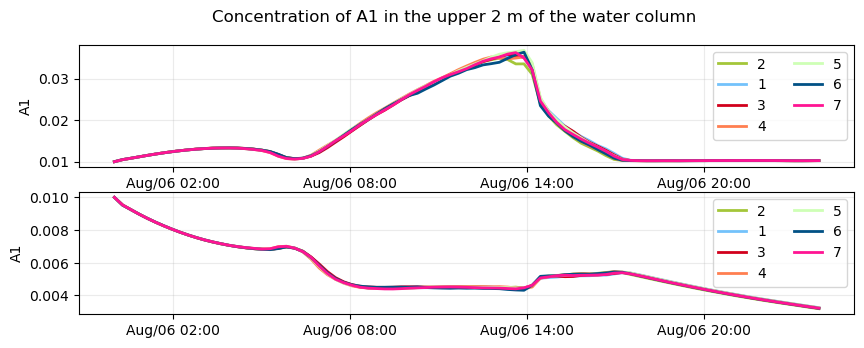

In [235]:
fig, axs = plt.subplots(figsize=(10, 3.5), nrows=2, sharey=False, sharex=False)

for im, model in enumerate(models):
    ds = models_list[model].ds
    kz = ds.algae1.sel(z=slice(1, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs[0].plot(models_list[model].dates, kz_av, color=colors[im], label=model, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
   
    ds = models_list[model].ds
    kz = ds.algae2.sel(z=slice(1, 0)) 
    kz_av = kz.mean(dim="z") 
    c1 = axs[1].plot(models_list[model].dates, kz_av, color=colors[im], label=model, linewidth=2) #, vmin=24, vmax=32) #, vmin=1.5e-7, vmax=1.5e-7)
   

for ax in axs:
        # axs[im].set_title("Model with Wind x %s" % model)
    format_date_ax(ax, hours=6)
    ax.legend(ncols=2) 
    ax.grid(alpha=0.25)
    ax.set_ylabel('A1')
    plt.suptitle("Concentration of A1 in the upper 2 m of the water column", fontsize=12)
# plt.tight_layout()
